In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [93]:
df = pd.read_csv("./data/df_final_janeiro_18.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Diagnostico_Doenca_Cronica,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos
0,3.0,55.0,2.0,1.0,1.0,1.0,6.0,5.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,3.0,0.0
1,2.0,19.0,2.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,6.0,1.0,2.0,3.0,2.0
2,3.0,45.0,2.0,2.0,4.0,1.0,8.0,8.0,4.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
3,3.0,58.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,...,2.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,1.0,0.0
4,2.0,28.0,2.0,4.0,4.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,2.0,4.0,1.0,1.0,3.0,5.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,3.0
90842,2.0,44.0,1.0,4.0,2.0,1.0,2.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,6.0,1.0,3.0,2.0,2.0
90843,2.0,32.0,2.0,4.0,1.0,2.0,4.0,4.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,4.0,3.0,1.0,3.0,0.0
90844,3.0,54.0,1.0,4.0,1.0,1.0,3.0,10.0,3.0,1.0,...,1.0,1.0,2.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0


In [94]:
df = df.drop(columns=["Grau_Limite_DORT", "Horas_TV", "Estado_Civil", "Sexo", "Apoio_Familiar", "Grau_Limite_Depressao", "Freq_Anedonia", "Freq_Problemas_Sono", "Grau_Limite_Depressao", "Grau_Limite_Doenca_Mental"])
df

,Autoavaliacao_Saude,Idade,Cor_Raca,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,Possui_Computador,Acesso_Internet,Freq_Cansaco,Freq_Depressao,Diagnostico_Doenca_Cronica,Pratica_Exercicio,Fuma,Freq_Alcool,Apoio_Amigos
0,3.0,55.0,1.0,1.0,6.0,5.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,3.0,2.0,0.0
1,2.0,19.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0
2,3.0,45.0,2.0,1.0,8.0,8.0,4.0,2.0,2.0,1.0,3.0,1.0,2.0,2.0,3.0,3.0,1.0
3,3.0,58.0,2.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0
4,2.0,28.0,4.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,4.0,1.0,3.0,5.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,3.0,3.0
90842,2.0,44.0,4.0,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,2.0
90843,2.0,32.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,3.0,1.0,0.0
90844,3.0,54.0,4.0,1.0,3.0,10.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,3.0


In [95]:
# target = "Saude_Boa"
target = "Autoavaliacao_Saude"

In [34]:
df['Saude_Boa'] = df['Autoavaliacao_Saude'].map({
    1: 1,  # Muito boa
    2: 1,  # Boa
    3: 0,  # Regular
    4: 0,  # Ruim
    5: 0   # Muito ruim
})
df

,Autoavaliacao_Saude,Idade,Cor_Raca,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,Possui_Computador,Acesso_Internet,Freq_Cansaco,Freq_Depressao,Diagnostico_Doenca_Cronica,Pratica_Exercicio,Fuma,Freq_Alcool,Apoio_Amigos,Saude_Boa
0,3.0,55.0,1.0,1.0,6.0,5.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,3.0,2.0,0.0,0
1,2.0,19.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1
2,3.0,45.0,2.0,1.0,8.0,8.0,4.0,2.0,2.0,1.0,3.0,1.0,2.0,2.0,3.0,3.0,1.0,0
3,3.0,58.0,2.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0,0
4,2.0,28.0,4.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90841,3.0,54.0,4.0,1.0,3.0,5.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,3.0,3.0,0
90842,2.0,44.0,4.0,1.0,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,2.0,1
90843,2.0,32.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,3.0,1.0,0.0,1
90844,3.0,54.0,4.0,1.0,3.0,10.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,3.0,1.0,3.0,0


Separando X e Y

In [96]:
X = df.drop(columns=[target, "Autoavaliacao_Saude"])
y = df[target]


Fazendo onehot encoding

In [97]:
cols_nominais = [
    'Sexo', 'Cor_Raca', 'Estado_Civil',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]

cols_nominais = [
    'Cor_Raca',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet', 'Diagnostico_Doenca_Cronica',
    'Pratica_Exercicio', 'Fuma'
]
X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

In [99]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

Utilizando CatBoostRegressor + SHAP

In [117]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Quantile:alpha=0.5",
    eval_metric="Quantile:alpha=0.5",
    random_seed=42,
    verbose=100,
    
)

model.fit(
    X_train2,
    y_train2,
    eval_set=(X_val, y_val),
    use_best_model=True
)

y_pred = model.predict(X_test)

0:	learn: 0.2916293	test: 0.2875871	best: 0.2875871 (0)	total: 5.19ms	remaining: 4.15s
100:	learn: 0.2422087	test: 0.2412659	best: 0.2412659 (100)	total: 393ms	remaining: 2.72s
200:	learn: 0.2412293	test: 0.2410458	best: 0.2410273 (182)	total: 768ms	remaining: 2.29s
300:	learn: 0.2405118	test: 0.2409288	best: 0.2409286 (298)	total: 1.23s	remaining: 2.04s
400:	learn: 0.2397752	test: 0.2410490	best: 0.2408938 (335)	total: 1.57s	remaining: 1.56s
500:	learn: 0.2392104	test: 0.2411545	best: 0.2408938 (335)	total: 1.86s	remaining: 1.11s
600:	learn: 0.2385044	test: 0.2413259	best: 0.2408938 (335)	total: 2.2s	remaining: 727ms
700:	learn: 0.2379812	test: 0.2414244	best: 0.2408938 (335)	total: 2.5s	remaining: 353ms
799:	learn: 0.2375188	test: 0.2414471	best: 0.2408938 (335)	total: 2.82s	remaining: 0us

bestTest = 0.2408937589
bestIteration = 335

Shrink model to first 336 iterations.


In [101]:
y_pred = model.predict(X_test)
y_pred = y_pred.clip(1, 5).round()

mae = mean_absolute_error(y_test, y_pred)
print("MAE final:", mae)


MAE final: 0.47526968518382623


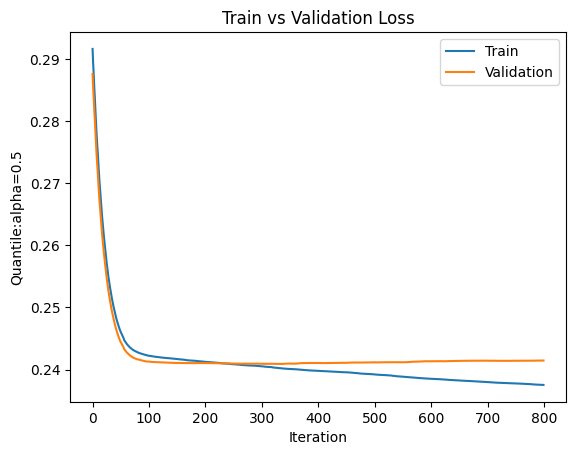

In [102]:
evals = model.get_evals_result()

train_loss = evals['learn']['Quantile:alpha=0.5']
val_loss   = evals['validation']['Quantile:alpha=0.5']

plt.figure()
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Quantile:alpha=0.5")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()


In [114]:
importances = model.get_feature_importance()
features = X_train.columns

imp_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print(imp_df.head(20))


                           feature  importance
17  Diagnostico_Doenca_Cronica_2.0   18.773217
5                     Freq_Cansaco   13.328403
0                            Idade   12.712671
6                   Freq_Depressao   10.534151
15           Possui_Computador_2.0    9.032719
18           Pratica_Exercicio_2.0    6.644526
14            Possui_Automovel_2.0    4.191465
1                  Nivel_Instrucao    4.091146
7                      Freq_Alcool    3.959616
2                  Total_Moradores    3.546982
4                    Qtd_Banheiros    3.159801
16             Acesso_Internet_2.0    2.659573
8                     Apoio_Amigos    2.422570
11                    Cor_Raca_4.0    2.141083
3                      Qtd_Comodos    1.382736
9                     Cor_Raca_2.0    0.892240
20                        Fuma_3.0    0.347611
12                    Cor_Raca_5.0    0.145886
19                        Fuma_2.0    0.017410
10                    Cor_Raca_3.0    0.015922


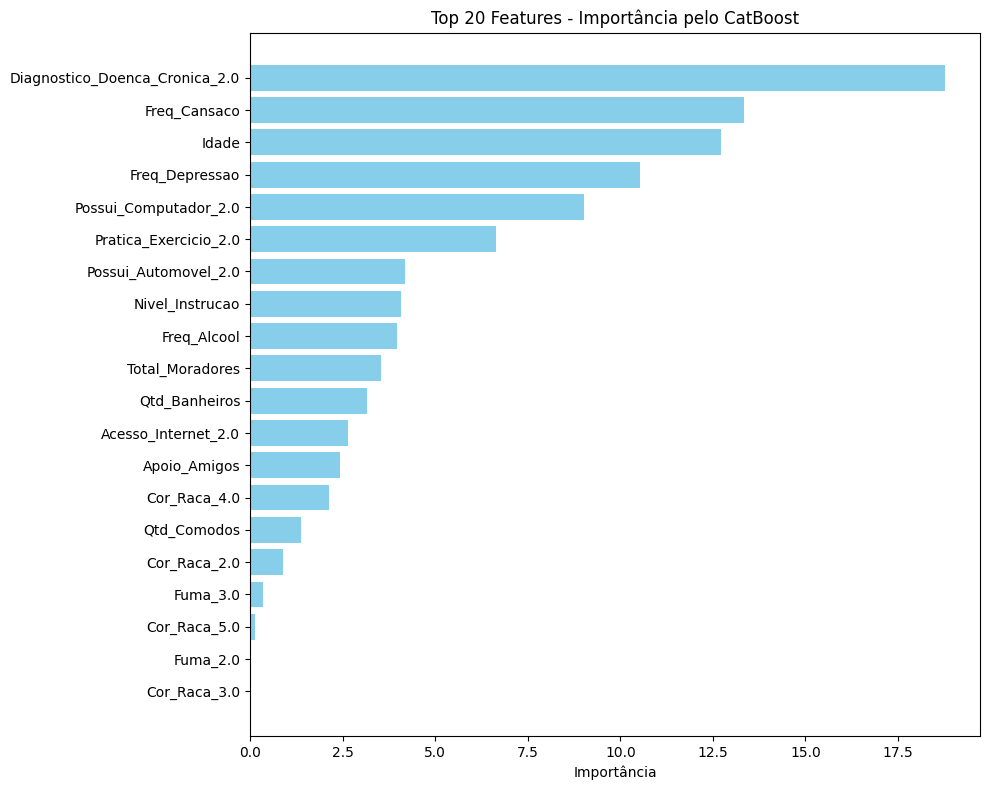

In [116]:
import matplotlib.pyplot as plt

imp_df_top20 = imp_df.head(20).sort_values("importance")

plt.figure(figsize=(10,8))
plt.barh(imp_df_top20["feature"], imp_df_top20["importance"], color="skyblue")
plt.xlabel("Importância")
plt.title("Top 20 Features - Importância pelo CatBoost")
plt.tight_layout()
plt.show()


fazendo cross validação

0:	learn: 0.2907156	test: 0.2913673	best: 0.2913673 (0)	total: 7.01ms	remaining: 5.6s
1:	learn: 0.2884399	test: 0.2890542	best: 0.2890542 (1)	total: 11.6ms	remaining: 4.62s
2:	learn: 0.2866209	test: 0.2872400	best: 0.2872400 (2)	total: 18.3ms	remaining: 4.85s
3:	learn: 0.2844524	test: 0.2850826	best: 0.2850826 (3)	total: 25.4ms	remaining: 5.05s
4:	learn: 0.2824608	test: 0.2831356	best: 0.2831356 (4)	total: 30.6ms	remaining: 4.86s
5:	learn: 0.2804656	test: 0.2811550	best: 0.2811550 (5)	total: 34.8ms	remaining: 4.61s
6:	learn: 0.2785584	test: 0.2793202	best: 0.2793202 (6)	total: 42.5ms	remaining: 4.82s
7:	learn: 0.2768140	test: 0.2776168	best: 0.2776168 (7)	total: 48.8ms	remaining: 4.83s
8:	learn: 0.2752540	test: 0.2760515	best: 0.2760515 (8)	total: 52.8ms	remaining: 4.64s
9:	learn: 0.2737017	test: 0.2744876	best: 0.2744876 (9)	total: 58.8ms	remaining: 4.64s
10:	learn: 0.2721481	test: 0.2729007	best: 0.2729007 (10)	total: 63.2ms	remaining: 4.54s
11:	learn: 0.2706653	test: 0.2714099	best:

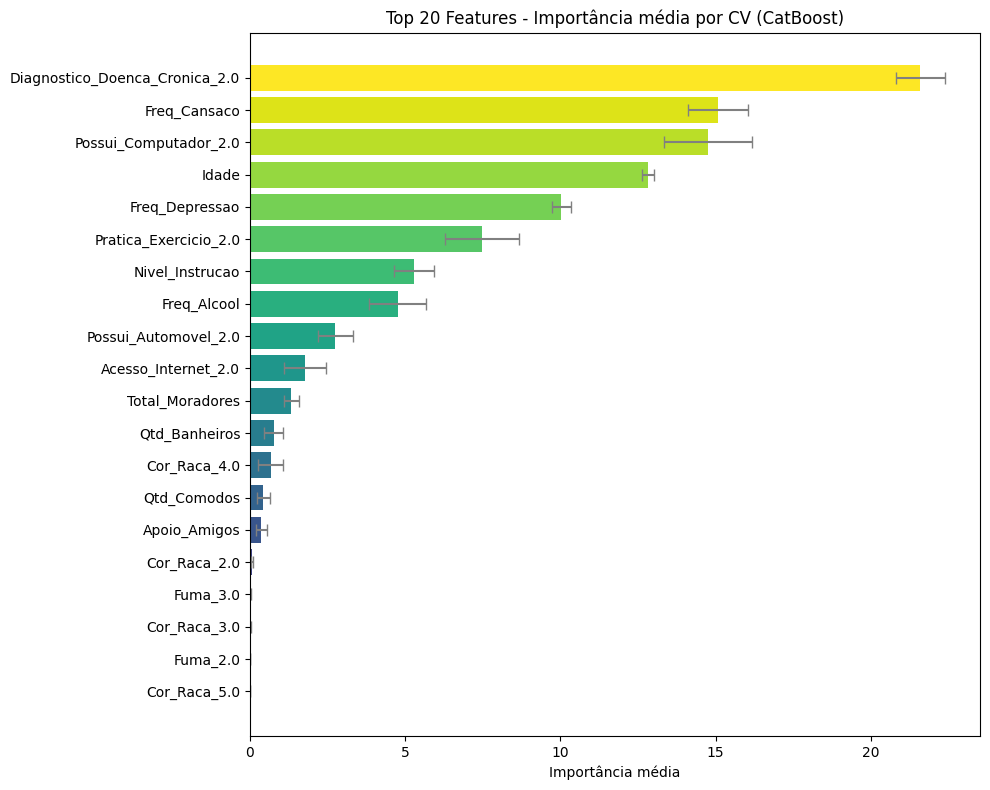

In [123]:
params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'Quantile:alpha=0.5',
    'eval_metric': 'Quantile:alpha=0.5',
    'random_seed': 42,
    'verbose': True
}


n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

feature_importances = []
fold = 1

for train_index, val_index in kf.split(X):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model = CatBoostRegressor(**params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        use_best_model=True,
    )

    importances = model.get_feature_importance()
    feature_importances.append(importances)
    best_iter = model.get_best_iteration()
    best_score = model.get_best_score()['validation']['Quantile:alpha=0.5']

    print(f"Fold {fold}: Melhor iteração = {best_iter}, Melhor loss no eval_set = {best_score:.4f}")
    fold += 1

# Média e desvio padrão das importâncias
importances_mean = np.mean(feature_importances, axis=0)
importances_std = np.std(feature_importances, axis=0)

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': importances_mean,
    'importance_std': importances_std
}).sort_values('importance_mean', ascending=False)

top20 = imp_df.head(20).sort_values('importance_mean')

colors = cm.viridis(np.linspace(0, 1, len(top20)))

plt.figure(figsize=(10,8))
plt.barh(
    top20['feature'],
    top20['importance_mean'],
    xerr=top20['importance_std'],
    color=colors,
    ecolor='gray',
    capsize=4
)
plt.xlabel('Importância média')
plt.title('Top 20 Features - Importância média por CV (CatBoost)')
plt.gca()
plt.tight_layout()
plt.show()


Fazendo Clusterização com as melhores Variáveis do SHAP

In [130]:
features_cluster = [
    "Diagnostico_Doenca_Cronica",
    "Idade",
    "Freq_Cansaco",
    "Pratica_Exercicio",
    "Freq_Depressao",
    "Freq_Problemas_Sono",
    "Nivel_Instrucao",
    "Freq_Alcool",
    "Freq_Anedonia",
    "Possui_Computador",
    "Possui_Automovel"
]

X_cluster = df[features_cluster]

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Utilizando K-means

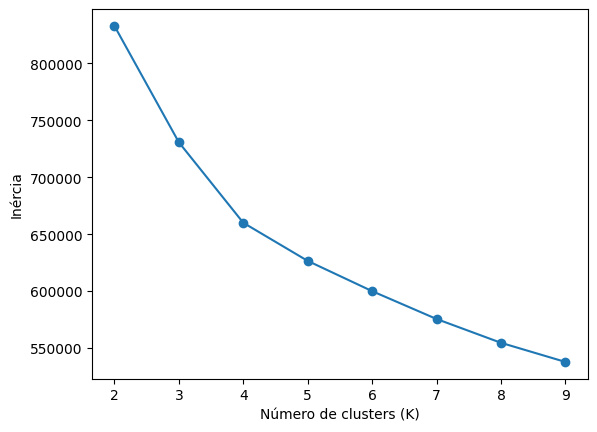

In [132]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.show()


In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts()

cluster
3    29678
1    24570
0    23377
2    13221
Name: count, dtype: int64

In [137]:
cluster_profile = (
    df.groupby("cluster")[features_cluster]
      .mean()
      .round(2)
)

cluster_profile

,Diagnostico_Doenca_Cronica,Idade,Freq_Cansaco,Pratica_Exercicio,Freq_Depressao,Freq_Problemas_Sono,Nivel_Instrucao,Freq_Alcool,Freq_Anedonia,Possui_Computador,Possui_Automovel
cluster,,,,,,,,,,,
0,1.13,64.15,1.36,1.77,1.25,1.68,1.80,1.25,1.22,1.86,1.71
1,1.51,41.69,1.39,1.32,1.17,1.42,1.17,1.94,1.20,1.06,1.19
2,1.21,46.51,3.08,1.69,2.68,3.02,1.42,1.56,2.75,1.68,1.64
3,1.84,36.25,1.28,1.65,1.18,1.25,1.19,1.79,1.19,1.94,1.76


In [138]:
import pandas as pd

crosstab_norm = pd.crosstab(
    df["cluster"],
    df["Autoavaliacao_Saude"],
    normalize="index"
)

crosstab_norm.round(3)


Autoavaliacao_Saude,1.0,2.0,3.0,4.0,5.0
cluster,,,,,
0,0.050,0.373,0.470,0.092,0.016
1,0.247,0.579,0.163,0.009,0.001
2,0.050,0.284,0.454,0.159,0.054
3,0.138,0.611,0.233,0.015,0.002
